## Importar librerias

In [ ]:
import os
from pathlib import Path
import pandas as pd
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import cv2
from scipy.stats import entropy
from skimage.restoration import estimate_sigma
from tqdm.auto import tqdm
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

## Datos

In [ ]:
path = kagglehub.dataset_download("tawsifurrahman/tuberculosis-tb-chest-xray-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tuberculosis-tb-chest-xray-dataset' dataset.
Path to dataset files: /kaggle/input/tuberculosis-tb-chest-xray-dataset


In [ ]:
base_path = Path(path) / "TB_Chest_Radiography_Database"

normal_path = base_path / "Normal"
tb_path = base_path / "Tuberculosis"

normal_imgs = list(normal_path.glob("*.png"))
tb_imgs = list(tb_path.glob("*.png"))

print(f"Normal: {len(normal_imgs)}")
print(f"Tuberculosis: {len(tb_imgs)}")

Normal: 3500
Tuberculosis: 700


## Construir primer DF

In [ ]:
data = []

for img_path in normal_imgs:

    img = Image.open(img_path)
    data.append({
        "Nombre_Archivo": img_path.name,
        "path": str(img_path),
        "clase": "Normal",
        "Ancho": img.width,
        "Alto": img.height,
        "Modo": img.mode
    })

for img_path in tb_imgs:

    img = Image.open(img_path)
    data.append({
        "Nombre_Archivo": img_path.name,
        "path": str(img_path),
        "clase": "Tuberculosis",
        "Ancho": img.width,
        "Alto": img.height,
        "Modo": img.mode
    })

df = pd.DataFrame(data)
df.head()

,Nombre_Archivo,path,clase,Ancho,Alto,Modo
0,Normal-859.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
1,Normal-158.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
2,Normal-1811.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
3,Normal-97.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB
4,Normal-1088.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,512,512,RGB


In [ ]:
print("Shape:", df.shape)

print("\n\tDISTRIBUCION DE CLASES")
print(df["clase"].value_counts())

print("\n\tARCHIVOS UNICOS")
print("Nombre_Archivo unicos:", df["Nombre_Archivo"].nunique())
print("Paths unicos:", df["path"].nunique())

print("\n\tDUPLICADOS EXACTOS")
print(df.duplicated().sum())

print("\n\tVALORES FALTANTES")
print(df.isna().sum())

print("\n\tDIMENSIONES")
print(
    df.groupby(["Ancho", "Alto"])
      .size()
      .sort_values(ascending=False)
)

print("\n\tMODOS DE IMAGEN")
print(df["Modo"].value_counts(dropna=False))

Shape: (4200, 6)

	DISTRIBUCION DE CLASES
clase
Normal          3500
Tuberculosis     700
Name: count, dtype: int64

	ARCHIVOS UNICOS
Nombre_Archivo unicos: 4200
Paths unicos: 4200

	DUPLICADOS EXACTOS
0

	VALORES FALTANTES
Nombre_Archivo    0
path              0
clase             0
Ancho             0
Alto              0
Modo              0
dtype: int64

	DIMENSIONES
Ancho  Alto
512    512     4200
dtype: int64

	MODOS DE IMAGEN
Modo
RGB    3892
L       308
Name: count, dtype: int64


## Probar metricas en una imagen

In [ ]:
# Division de la radiografia en 6 regiones
def dividir_en_regiones(img):
    """
    Divide una radiografia grayscale en seis regiones espaciales
    SI: Superior Izquierda
    SD: Superior Derecha
    MI: Media Izquierda
    MD: Media Derecha
    LI: Inferior Izquierda
    LD: Inferior Derecha
    """

    h, w = img.shape

    x_mid = w // 2
    y1 = h // 3
    y2 = 2 * h // 3

    return {
        "SI": img[0:y1, 0:x_mid],
        "SD": img[0:y1, x_mid:w],
        "MI": img[y1:y2, 0:x_mid],
        "MD": img[y1:y2, x_mid:w],
        "LI": img[y2:h, 0:x_mid],
        "LD": img[y2:h, x_mid:w]
    }

# extraccion metricas de calidad

def calcular_metricas(region):
    """
    Calcula metricas sobre una region grayscale uint8
    """
    # Brightness
    brightness = np.mean(region)

    # contrast
    contrast = np.std(region)

    # ENTROPY DE SHANNON
    hist = cv2.calcHist([region], [0], None, [256], [0, 256]).flatten()

    hist_prob = hist / hist.sum()

    region_entropy = entropy(hist_prob, base=2)

    # blur score
    # Mayor varianza del Laplaciano -> generalmente ma detalle/nitidez
    blur_score = cv2.Laplacian(region, cv2.CV_64F).var()

    # underexposed ratio
    underexposed_ratio = np.mean(region < 5)

    # overexposed ratio
    overexposed_ratio = np.mean(region > 250)

    # noise estimate
    if np.min(region) == np.max(region):
        noise_estimate = 0.0
    else:
        noise_estimate = estimate_sigma(
            region,
            channel_axis=None,
            average_sigmas=True
        )

    return {
        "brightness": brightness,
        "contrast": contrast,
        "entropy": region_entropy,
        "blur_score": blur_score,
        "underexposed_ratio": underexposed_ratio,
        "overexposed_ratio": overexposed_ratio,
        "noise_estimate": noise_estimate
    }

# Prueba con una sola radiografia

row = df.iloc[0]
img = cv2.imread(row["path"], cv2.IMREAD_GRAYSCALE)

print("Archivo:", row["Nombre_Archivo"])
print("Clase:", row["clase"])
print("Shape:", img.shape)
print("dtype:", img.dtype)

regiones = dividir_en_regiones(img)

print("\nMetricas por region:\n")

for nombre_region, region in regiones.items():
    metricas = calcular_metricas(region)
    print(f"--- {nombre_region} ---")
    print("Shape region:", region.shape)
    for nombre_metrica, valor in metricas.items():
        print(f"{nombre_metrica:25s}: {valor:.6f}")
    print()

Archivo: Normal-859.png
Clase: Normal
Shape: (512, 512)
dtype: uint8

Metricas por region:

--- SI ---
Shape region: (170, 256)
brightness               : 95.503102
contrast                 : 47.071020
entropy                  : 7.365115
blur_score               : 66.396156
underexposed_ratio       : 0.047932
overexposed_ratio        : 0.000000
noise_estimate           : 1.105299

--- SD ---
Shape region: (170, 256)
brightness               : 84.439384
contrast                 : 40.960259
entropy                  : 7.183282
blur_score               : 94.155766
underexposed_ratio       : 0.044531
overexposed_ratio        : 0.000000
noise_estimate           : 1.091993

--- MI ---
Shape region: (171, 256)
brightness               : 96.099392
contrast                 : 48.118483
entropy                  : 7.384577
blur_score               : 57.759767
underexposed_ratio       : 0.000914
overexposed_ratio        : 0.000000
noise_estimate           : 1.173133

--- MD ---
Shape region: (171, 2

## Extraccion de metricas por region para el dataset

In [ ]:
registros = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Procesando radiografias"):

    # todas las imagenes se procesan como un uico canal grayscale
    img = cv2.imread(
        row["path"],
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        print(f"No se pudo leer: {row['path']}")
        continue

    regiones = dividir_en_regiones(img)
    registro = {
        "Nombre_Archivo": row["Nombre_Archivo"],
        "path": row["path"],
        "clase": row["clase"]
    }

    for nombre_region, region in regiones.items():
        metricas = calcular_metricas(region)
        for nombre_metrica, valor in metricas.items():
            registro[f"{nombre_region}_{nombre_metrica}"] = valor
    registros.append(registro)

regional_quality_df = pd.DataFrame(registros)

Procesando radiografias:   0%|          | 0/4200 [00:00<?, ?it/s]

In [ ]:
print("Shape:", regional_quality_df.shape)
print("\nPrimeras columnas:")
print(regional_quality_df.columns.tolist())
print("\nValores faltantes:")
print(regional_quality_df.isna().sum().sum())
print("\nnummero de imagenes:")
print(regional_quality_df["Nombre_Archivo"].nunique())
regional_quality_df.head()

Shape: (4200, 45)

Primeras columnas:
['Nombre_Archivo', 'path', 'clase', 'SI_brightness', 'SI_contrast', 'SI_entropy', 'SI_blur_score', 'SI_underexposed_ratio', 'SI_overexposed_ratio', 'SI_noise_estimate', 'SD_brightness', 'SD_contrast', 'SD_entropy', 'SD_blur_score', 'SD_underexposed_ratio', 'SD_overexposed_ratio', 'SD_noise_estimate', 'MI_brightness', 'MI_contrast', 'MI_entropy', 'MI_blur_score', 'MI_underexposed_ratio', 'MI_overexposed_ratio', 'MI_noise_estimate', 'MD_brightness', 'MD_contrast', 'MD_entropy', 'MD_blur_score', 'MD_underexposed_ratio', 'MD_overexposed_ratio', 'MD_noise_estimate', 'LI_brightness', 'LI_contrast', 'LI_entropy', 'LI_blur_score', 'LI_underexposed_ratio', 'LI_overexposed_ratio', 'LI_noise_estimate', 'LD_brightness', 'LD_contrast', 'LD_entropy', 'LD_blur_score', 'LD_underexposed_ratio', 'LD_overexposed_ratio', 'LD_noise_estimate']

Valores faltantes:
0

nummero de imagenes:
4200


,Nombre_Archivo,path,clase,SI_brightness,SI_contrast,SI_entropy,SI_blur_score,SI_underexposed_ratio,SI_overexposed_ratio,SI_noise_estimate,...,LI_underexposed_ratio,LI_overexposed_ratio,LI_noise_estimate,LD_brightness,LD_contrast,LD_entropy,LD_blur_score,LD_underexposed_ratio,LD_overexposed_ratio,LD_noise_estimate
0,Normal-859.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,95.503102,47.071020,7.365115,66.396156,0.047932,0.000000,1.105299,...,0.113350,0.0,0.981154,115.342174,86.853609,6.470372,29.445586,0.267727,0.0,0.994460
1,Normal-158.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,90.281641,42.112113,6.625253,35.693027,0.000161,0.000000,0.760368,...,0.001782,0.0,0.598981,96.989629,56.254708,6.225671,20.642028,0.002102,0.0,0.574152
2,Normal-1811.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,141.896048,69.787955,7.040375,158.099398,0.090901,0.000965,0.512971,...,0.061289,0.0,0.438484,180.958539,51.469750,7.093519,167.151963,0.000000,0.0,0.463313
3,Normal-97.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,97.782123,59.854598,7.148809,55.033798,0.158180,0.000000,0.956326,...,0.221765,0.0,0.734648,143.414291,71.866757,7.615141,45.870127,0.047492,0.0,1.012636
4,Normal-1088.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,77.214017,47.760289,7.224046,53.066625,0.084674,0.000000,0.969631,...,0.000662,0.0,0.999330,145.327942,89.182566,6.697200,24.605796,0.206186,0.0,0.815788


Identificar faltante

In [ ]:
columnas_con_nan = regional_quality_df.columns[regional_quality_df.isna().any()].tolist()

print("Columnas con NaN:")
print(columnas_con_nan)
print("\nCantidad de NaN por columna:")
print(regional_quality_df[columnas_con_nan].isna().sum())

filas_con_nan = regional_quality_df[regional_quality_df.isna().any(axis=1)]

print("\nNumero de imagenes afectadas:")
print(len(filas_con_nan))

print("\nImagen/es afectada/s:")
filas_con_nan

Columnas con NaN:
[]

Cantidad de NaN por columna:
Series([], dtype: float64)

Numero de imagenes afectadas:
0

Imagen/es afectada/s:


,Nombre_Archivo,path,clase,SI_brightness,SI_contrast,SI_entropy,SI_blur_score,SI_underexposed_ratio,SI_overexposed_ratio,SI_noise_estimate,...,LI_underexposed_ratio,LI_overexposed_ratio,LI_noise_estimate,LD_brightness,LD_contrast,LD_entropy,LD_blur_score,LD_underexposed_ratio,LD_overexposed_ratio,LD_noise_estimate


0 Faltantes

## Dataframe long para un analisis estadistico

In [ ]:
regiones = ["SI", "SD", "MI", "MD", "LI", "LD"]

metricas = ["brightness","contrast","entropy","blur_score","underexposed_ratio","overexposed_ratio","noise_estimate"]
long_parts = []

for region in regiones:

    columnas_region = [f"{region}_{metrica}" for metrica in metricas]

    temp = regional_quality_df[["Nombre_Archivo", "path", "clase"] + columnas_region].copy()

    temp["region"] = region

    temp = temp.rename(
        columns={
            f"{region}_{metrica}": metrica
            for metrica in metricas
        }
    )

    long_parts.append(temp)

regional_quality_long_df = pd.concat(long_parts,ignore_index=True)

# Orden logico de las regiones
regional_quality_long_df["region"] = pd.Categorical(regional_quality_long_df["region"],categories=regiones,ordered=True)
print("Shape formato ancho :", regional_quality_df.shape)
print("Shape formato long :", regional_quality_long_df.shape)
print("\nNaN totales:")
print(regional_quality_long_df.isna().sum().sum())
regional_quality_long_df.head(12)

Shape formato ancho : (4200, 45)
Shape formato long : (25200, 11)

NaN totales:
0


,Nombre_Archivo,path,clase,brightness,contrast,entropy,blur_score,underexposed_ratio,overexposed_ratio,noise_estimate,region
0,Normal-859.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,95.503102,47.071020,7.365115,66.396156,0.047932,0.000000,1.105299,SI
1,Normal-158.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,90.281641,42.112113,6.625253,35.693027,0.000161,0.000000,0.760368,SI
2,Normal-1811.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,141.896048,69.787955,7.040375,158.099398,0.090901,0.000965,0.512971,SI
3,Normal-97.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,97.782123,59.854598,7.148809,55.033798,0.158180,0.000000,0.956326,SI
4,Normal-1088.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,77.214017,47.760289,7.224046,53.066625,0.084674,0.000000,0.969631,SI
5,Normal-893.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,123.681480,58.289784,7.526640,82.980450,0.000000,0.000000,0.641986,SI
6,Normal-37.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,71.728883,50.202434,6.570915,72.737061,0.194485,0.000000,0.483272,SI
7,Normal-1902.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,119.726287,58.039750,6.660236,115.750938,0.008594,0.000000,0.438484,SI
8,Normal-373.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,147.267142,59.922682,7.242383,139.957606,0.000000,0.000000,0.666814,SI
9,Normal-2118.png,/kaggle/input/tuberculosis-tb-chest-xray-datas...,Normal,97.648369,53.453913,7.528471,100.704700,0.023529,0.000000,1.012636,SI


## Tabla descriptiva por region

In [ ]:
metricas = ["brightness", "contrast", "entropy", "blur_score", "underexposed_ratio", "overexposed_ratio", "noise_estimate"]

resumen_regional = (regional_quality_long_df.groupby("region", observed=True)[metricas].agg([
        "count",
        "mean",
        "std",
        "min",
        "median",
        "max"
    ])
)
with pd.option_context('display.max_columns', None):
    display(resumen_regional)

#resumen_regional

brightness                                                            \
            count        mean        std        min      median         max   
region                                                                        
SI           4200  105.888721  29.999702   0.000000  100.333456  204.060983   
SD           4200  107.153545  30.488771   0.119692  102.061179  255.000000   
MI           4200  123.153356  26.980691  32.464707  119.219515  238.045504   
MD           4200  129.588203  27.081640  38.013638  126.532712  255.000000   
LI           4200  155.760541  34.299618   5.118261  156.361145  255.000000   
LD           4200  154.306899  33.896801   8.391584  154.700932  255.000000   

       contrast                                                       entropy  \
          count       mean        std      min     median         max   count   
region                                                                          
SI         4200  51.026563   9.926335  0.00000  52.688346   88.727961    4200   
SD         4200  50.764533  10.219879  0.00000  52.289501   91.864945    4200   
MI         4200  46.414740  10.718065  5.76298  48.151260   85.281257    4200   
MD         4200  46.832376  11.727872  0.00000  48.738460  106.920933    4200   
LI         4200  61.545633  19.664368  0.00000  64.467055  109.982020    4200   
LD         4200  60.540787  19.571123  0.00000  64.275025  112.598336    4200   

                                                         blur_score  \
            mean       std       min    median       max      count   
region                                                                
SI      7.025314  0.518714  0.000000  7.111561  7.790632       4200   
SD      7.041481  0.585827  0.000000  7.156261  7.769032       4200   
MI      7.107513  0.401318  1.806913  7.213949  7.737411       4200   
MD      7.102634  0.509861  0.000000  7.239173  7.760081       4200   
LI      6.776970  0.731355  0.000000  6.911057  7.863981       4200   
LD      6.830561  0.727310  0.000000  6.965000  7.867067       4200   

                                                                   \
              mean         std       min      median          max   
region                                                              
SI      120.204886  177.530881  0.000000   66.141509  1850.477911   
SD      169.734987  166.994761  0.000000  128.686670  1476.238500   
MI       71.048008   77.469362  1.426168   56.257457  1128.237486   
MD       73.753006   97.987559  0.000000   57.787800  1749.844310   
LI      115.925992  183.591258  0.000000   37.364591  1423.990046   
LD      108.750001  155.253111  0.000000   42.328501  1149.365819   

       underexposed_ratio                                               \
                    count      mean       std  min    median       max   
region                                                                   
SI                   4200  0.070821  0.093486  0.0  0.041774  1.000000   
SD                   4200  0.067206  0.089735  0.0  0.037833  1.000000   
MI                   4200  0.015564  0.039817  0.0  0.000000  0.600420   
MD                   4200  0.014177  0.037456  0.0  0.000000  0.416484   
LI                   4200  0.049694  0.084695  0.0  0.011445  0.958996   
LD                   4200  0.049448  0.083711  0.0  0.011719  0.960344   

       overexposed_ratio                                            \
                   count      mean       std  min median       max   
region                                                               
SI                  4200  0.001446  0.010881  0.0    0.0  0.263649   
SD                  4200  0.003509  0.047276  0.0    0.0  1.000000   
MI                  4200  0.000800  0.019481  0.0    0.0  0.835960   
MD                  4200  0.003236  0.048268  0.0    0.0  1.000000   
LI                  4200  0.009944  0.062038  0.0    0.0  1.000000   
LD                  4200  0.012368  0.070834  0.0    0.0  1.000000   

     

In [ ]:
percentiles_regionales = (regional_quality_long_df.groupby("region", observed=True)[metricas].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]))
percentiles_regionales

brightness   contrast   entropy  blur_score  underexposed_ratio  \
region                                                                         
SI     0.01   47.243242  24.639375  5.538647    4.698204            0.000000   
       0.05   64.970700  32.463006  6.256985   10.546163            0.000000   
       0.25   84.158088  45.267806  6.799382   46.531918            0.002447   
       0.50  100.333456  52.688346  7.111561   66.141509            0.041774   
       0.75  126.114947  57.920460  7.363446  105.253268            0.101528   
       0.95  161.231071  63.994655  7.578638  529.293350            0.245531   
       0.99  177.338131  71.816003  7.663417  904.792851            0.377861   
SD     0.01   47.006084  23.136812  5.271688    4.550369            0.000000   
       0.05   65.239874  32.286738  6.293710   10.624038            0.000000   
       0.25   85.825500  44.760648  6.828122   75.626489            0.001838   
       0.50  102.061179  52.289501  7.156261  128.686670            0.037833   
       0.75  126.547754  57.516331  7.385569  207.218520            0.101143   
       0.95  162.552683  64.618720  7.578010  476.758971            0.225496   
       0.99  179.688362  73.466736  7.653382  885.607328            0.352539   
MI     0.01   66.382232  20.468099  5.932324    4.544266            0.000000   
       0.05   82.486321  26.218956  6.341515    7.779166            0.000000   
       0.25  104.667717  39.531465  6.926667   42.054742            0.000000   
       0.50  119.219515  48.151260  7.213949   56.257457            0.000000   
       0.75  142.296567  53.737661  7.396802   69.008362            0.011045   
       0.95  169.952692  61.514217  7.541775  194.974414            0.082032   
       0.99  181.915812  70.533469  7.617979  422.353233            0.177587   
MD     0.01   68.061461  19.418342  5.813733    4.140328            0.000000   
       0.05   87.990505  24.950296  6.268414    7.137344            0.000000   
       0.25  111.418591  39.564751  6.908019   41.403301            0.000000   
       0.50  126.532712  48.738460  7.239173   57.787800            0.000000   
       0.75  149.438025  54.792826  7.425123   70.876590            0.007795   
       0.95  174.409924  62.971374  7.567070  188.954194            0.082424   
       0.99  187.377577  73.032225  7.642264  555.404089            0.176228   
LI     0.01   73.040938  13.887209  4.390089    3.694982            0.000000   
       0.05   99.188230  25.156347  5.610024    9.439372            0.000000   
       0.25  132.672520  48.124023  6.501580   25.921108            0.000000   
       0.50  156.361145  64.467055  6.911057   37.364591            0.011445   
       0.75  180.133663  77.294523  7.229587  127.684037            0.067651   
       0.95  210.228504  88.094369  7.581309  554.839989            0.210250   
       0.99  225.734274  94.996196  7.726088  906.311699            0.362577   
LD     0.01   72.964799  14.016488  4.523520    3.144250            0.000000   
       0.05   98.771696  24.636164  5.721373   10.203414            0.000000   
       0.25  131.043294  46.650348  6.571537   29.587145            0.000000   
       0.50  154.700932  64.275025  6.965000   42.328501            0.011719   
       0.75  178.209173  76.079011  7.274062  122.167243            0.068753   
       0.95  208.654653  86.556017  7.594596  492.850792            0.209492   
       0.99  224.623474  92.915738  7.727735  706.372545            0.361431   

             overexposed_ratio  noise_estimate  
region                                          
SI     0.01           0.000000        0.185325  
       0.05           0.000000        0.228330  
       0.25           0.000000        0.576647  
       0.50           0.000000        0.809135  
       0.75           0.000000        0.981154  
       0.95           0.003608        1.148304  
       0.99           0.037017        1.254272  
SD     0.01           0.000000        0.185325  
  

Vemos metricas que varian bastante por región, por ejemplo:
- La mediana de Brightness suele aumentar de la parte superior a la inferior de la imagen
- La mediana de underexposed_ratio tiene valores muy diferentes dependiendo de si es una zona superior, media o inferior
- Los percentiles de blur_score están muy sesgados, por ejemplo, $P_{50}=66$ pero $p_{95}=529$

Entre otras que se nota cierto sesgo

## Resumen por clase (TB O NO) por region

In [ ]:
metricas = ["brightness", "contrast", "entropy", "blur_score", "underexposed_ratio", "overexposed_ratio", "noise_estimate"]

resumen_clase_region = (regional_quality_long_df.groupby(["clase", "region"],observed=True)[metricas].agg([
      "count",
      "median",
      lambda x: x.quantile(0.25),
      lambda x: x.quantile(0.75)
    ])
)

# nombres mas claros para q1 y 13
resumen_clase_region.columns = pd.MultiIndex.from_tuples([
    (metrica, "count" if estadistico == "count"
               else "median" if estadistico == "median"
               else "Q1" if estadistico == "<lambda_0>"
               else "Q3")
    for metrica, estadistico in resumen_clase_region.columns
])

with pd.option_context('display.max_columns', None):
    display(resumen_clase_region)

#resumen_clase_region

brightness                                     contrast  \
                         count      median          Q1          Q3    count   
clase        region                                                           
Normal       SI           3500   96.930963   82.825236  121.064631     3500   
             SD           3500   98.977711   84.790682  121.716814     3500   
             MI           3500  119.338565  105.705466  142.585064     3500   
             MD           3500  126.718133  112.591134  149.923314     3500   
             LI           3500  160.519554  137.945067  183.937980     3500   
             LD           3500  158.954496  135.270405  181.553477     3500   
Tuberculosis SI            700  121.865097  102.727964  142.310915      700   
             SD            700  121.101677   93.443463  142.809467      700   
             MI            700  118.934073   96.252598  141.708745      700   
             MD            700  124.063814   99.246916  148.503872      700   
             LI            700  131.262872  106.737659  154.944279      700   
             LD            700  134.249132  110.865183  157.565989      700   

                                                     entropy            \
                        median         Q1         Q3   count    median   
clase        region                                                      
Normal       SI      53.917532  47.378708  58.425076    3500  7.161614   
             SD      53.406938  46.943296  57.889088    3500  7.198287   
             MI      48.609104  40.849385  53.582315    3500  7.263471   
             MD      48.936835  40.825482  54.492978    3500  7.302046   
             LI      66.539362  49.897985  78.533760    3500  6.971027   
             LD      65.763210  48.468493  76.749587    3500  7.028201   
Tuberculosis SI      44.546621  36.308668  52.263376     700  6.899054   
             SD      43.898177  36.024780  52.555392     700  6.861648   
             MI      44.156130  33.336828  55.484996     700  6.871428   
             MD      46.965863  29.787549  57.742983     700  6.828278   
             LI      55.380394  43.286337  67.416102     700  6.626367   
             LD      57.790085  40.784366  72.145197     700  6.569978   

                                        blur_score                         \
                           Q1        Q3      count      median         Q1   
clase        region                                                         
Normal       SI      6.853631  7.392822       3500   72.458369  56.907766   
             SD      6.913559  7.409894       3500  149.338378  98.841789   
             MI      7.010454  7.413651       3500   58.931100  50.747020   
             MD      7.001602  7.447749       3500   61.405248  50.580370   
             LI      6.573157  7.271227       3500   40.371813  28.777004   
             LD      6.681816  7.317823       3500   45.875081  33.157392   
Tuberculosis SI      6.601395  7.132218        700   19.074096   9.276370   
             SD      6.584259  7.163871        700   18.414292   9.554333   
             MI      6.461950  7.155978        700   10.630011   7.280514   
             MD      6.334450  7.146735        700   10.290614   6.665813   
             LI      6.194668  6.940795        700   18.614464   8.348444   
             LD      6.087379  6.906508        700   21.174661   8.132719   

                                underexposed_ratio                      \
                             Q3              count    median        Q1   
clase        region                                                      
Normal       SI      119.688651               3500  0.047197  0.007784   
             SD      226.088220               3500  0.045198  0.005193   
             MI       73.730013               3500  0.000000  0.000000   
             MD       73.623380               3500  0.000000  0.000000   
             LI      143.284822               350

Aqui se observan patrones más claros.

### Brightness

En terminos de la mediana de brightness, TB Las regiones superiores son más brillantes, las medias son bastante similares y las inferiores son más oscuras que las Normales

### Contrast
En cuanto a esta, la mediana no muestra cambios drasticos entre TB y Normal, se observan ciertas diferencias pero no parecen de una gran magnitud

### Entropy

Para esta métrica se observa como a pesar de no tener diferencias enormes ni siquiera para la escala de esta, en las muestras de TB, su mediana es menor en todas las regiones correspondientes con las Normales

### Blur score

Se debe tener cuidado con la interpretación acá, pues la diferencia de las medias entre TB y Normales son demasiado notorias, no debemos supone que la prescencia de TB hace mas borrosa la imagen o radiografía, se debe analisar que es el fenomeno que aqui ocurre

### Under exposed ratio

Se observan diferencias, donde en regiones, las Normales tienen mayor area negra que las TB, esto puede deberse relacionado a el encuadre de la radiografía

### Noise estimate

Se notan grandes diferencias y valores sospechosamente repetidos, se debe analizar tambien

Con esto podemos concluir que las regiones si parecen aportar información de la presencia de TB o no, aunque aun necesitamos estudiar ciertas métricas para tener una conclusión mas contundente

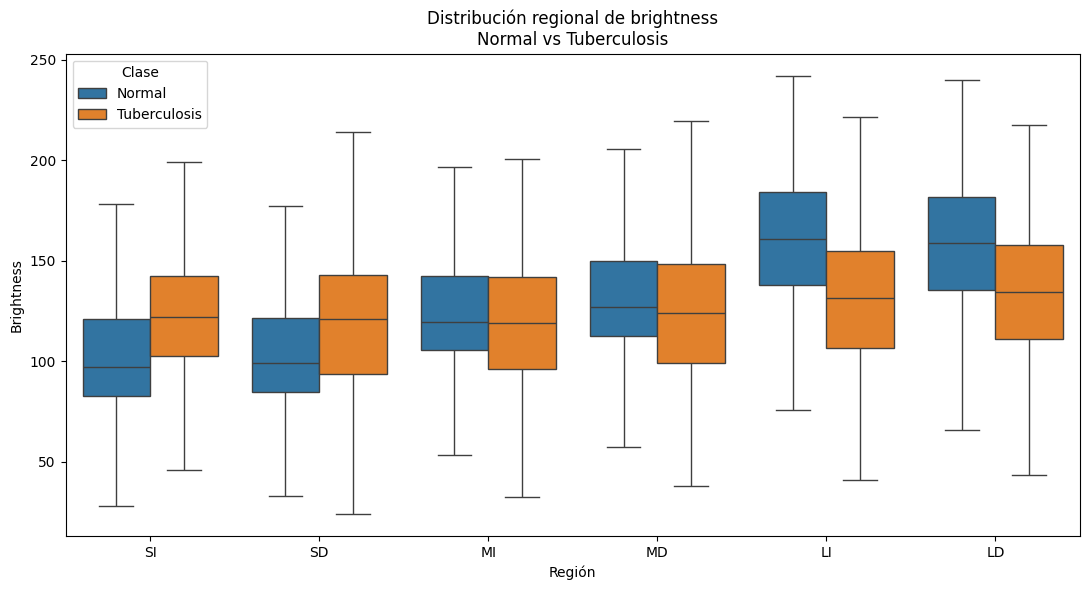

In [ ]:
plt.figure(figsize=(11, 6))
sns.boxplot(
    data=regional_quality_long_df,
    x="region",
    y="brightness",
    hue="clase",
    showfliers=False
)

plt.title("Distribución regional de brightness\nNormal vs Tuberculosis")
plt.xlabel("Región")
plt.ylabel("Brightness")
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

In [ ]:
brightness_mediana = (regional_quality_long_df.groupby(["region", "clase"], observed=True)["brightness"].median().unstack())
brightness_mediana["TB_minus_Normal"] = (brightness_mediana["Tuberculosis"]- brightness_mediana["Normal"])
brightness_mediana["Cambio_pct_vs_Normal"] = (brightness_mediana["TB_minus_Normal"]/ brightness_mediana["Normal"]* 100)
brightness_mediana.round(2)

clase,Normal,Tuberculosis,TB_minus_Normal,Cambio_pct_vs_Normal
region,,,,
SI,96.93,121.87,24.93,25.72
SD,98.98,121.10,22.12,22.35
MI,119.34,118.93,-0.40,-0.34
MD,126.72,124.06,-2.65,-2.09
LI,160.52,131.26,-29.26,-18.23
LD,158.95,134.25,-24.71,-15.54


In [ ]:
# idea de interpretacion :La mediana de brightness en SI para imagenes TB es aproximadamente 25.7% mayor que la mediana de las imagenes normales

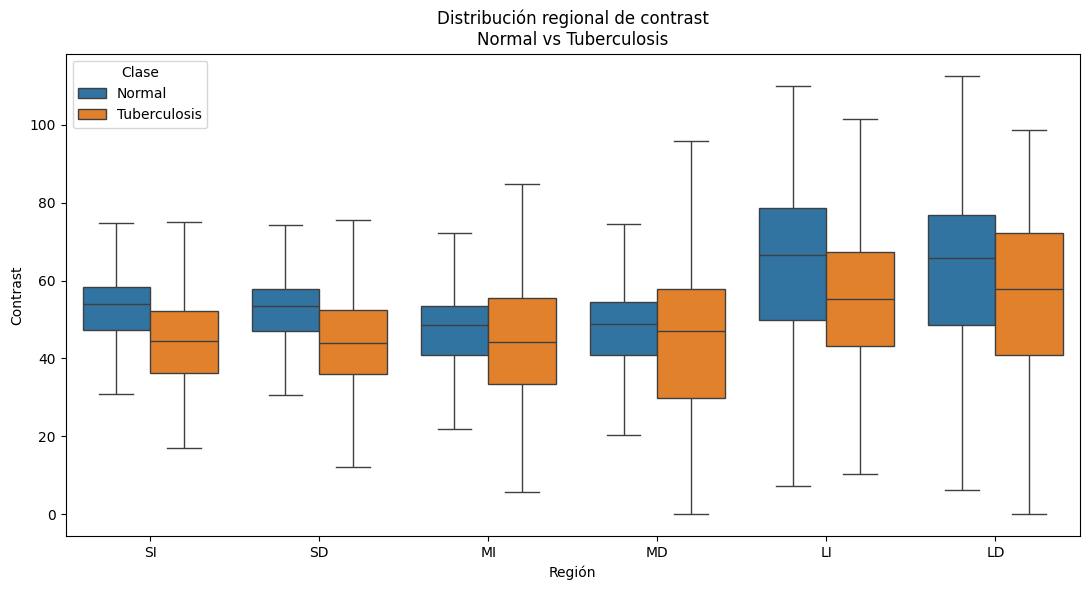

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=regional_quality_long_df,
    x="region",
    y="contrast",
    hue="clase",
    showfliers=False
)

plt.title("Distribución regional de contrast\nNormal vs Tuberculosis")
plt.xlabel("Región")
plt.ylabel("Contrast")
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

Confirmamos lo mencionado antes, la mediana para muestras Normales es mayor a las de TB en todas las regiones

In [ ]:
contrast_mediana = (regional_quality_long_df.groupby(["region", "clase"],observed=True)["contrast"].median().unstack())
contrast_mediana["TB_minus_Normal"] = (contrast_mediana["Tuberculosis"]- contrast_mediana["Normal"])
contrast_mediana["Cambio_pct_vs_Normal"] = (contrast_mediana["TB_minus_Normal"]/ contrast_mediana["Normal"]* 100)
contrast_mediana.round(2)

clase,Normal,Tuberculosis,TB_minus_Normal,Cambio_pct_vs_Normal
region,,,,
SI,53.92,44.55,-9.37,-17.38
SD,53.41,43.90,-9.51,-17.80
MI,48.61,44.16,-4.45,-9.16
MD,48.94,46.97,-1.97,-4.03
LI,66.54,55.38,-11.16,-16.77
LD,65.76,57.79,-7.97,-12.12


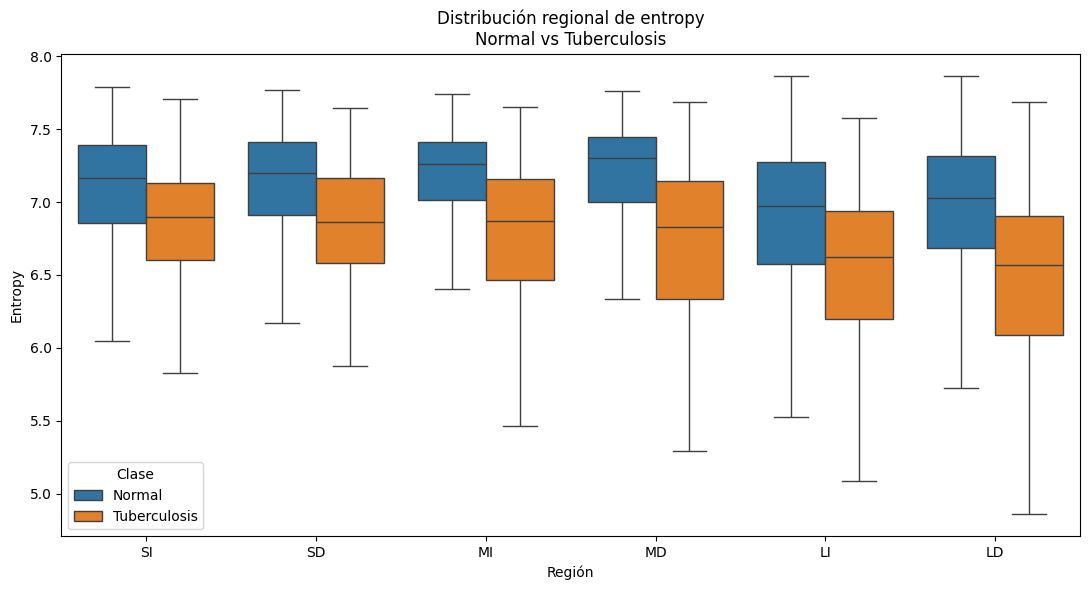

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=regional_quality_long_df,
    x="region",
    y="entropy",
    hue="clase",
    showfliers=False
)

plt.title("Distribución regional de entropy\nNormal vs Tuberculosis")
plt.xlabel("Región")
plt.ylabel("Entropy")
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

In [ ]:
entropy_mediana = (regional_quality_long_df.groupby(["region", "clase"],observed=True)["entropy"].median().unstack())

entropy_mediana["TB_minus_Normal"] = (entropy_mediana["Tuberculosis"]- entropy_mediana["Normal"])

entropy_mediana["Cambio_pct_vs_Normal"] = (entropy_mediana["TB_minus_Normal"]/ entropy_mediana["Normal"]* 100)

entropy_mediana.round(3)

clase,Normal,Tuberculosis,TB_minus_Normal,Cambio_pct_vs_Normal
region,,,,
SI,7.162,6.899,-0.263,-3.666
SD,7.198,6.862,-0.337,-4.677
MI,7.263,6.871,-0.392,-5.397
MD,7.302,6.828,-0.474,-6.488
LI,6.971,6.626,-0.345,-4.944
LD,7.028,6.570,-0.458,-6.520


### Analisemos blur_scores

Blur_score tiene una cola derecha, recordemos que  $P_{50}=66$ pero $p_{95}=529$, por lo que un boxplot lineal puede quedar dominado por valores extremos.

Haremos uso de

$$log(1+blur\_score)$$

Para comprimir la escala

In [ ]:
regional_quality_long_df["log_blur_score"] = np.log1p(regional_quality_long_df["blur_score"])

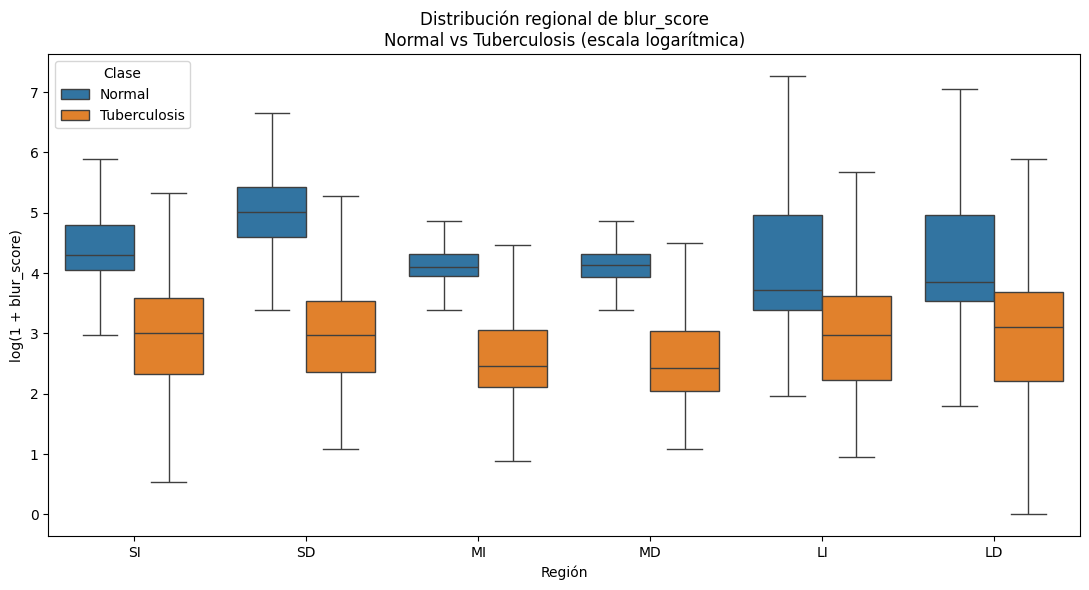

In [ ]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=regional_quality_long_df,
    x="region",
    y="log_blur_score",
    hue="clase",
    showfliers=False
)

plt.title("Distribución regional de blur_score\n""Normal vs Tuberculosis (escala logarítmica)")

plt.xlabel("Región")
plt.ylabel("log(1 + blur_score)")
plt.legend(title="Clase")
plt.tight_layout()
plt.show()

La tabla la mantenemos en las unidades originales, no la escalamos, para permitir mejor interpretación

In [ ]:
blur_mediana = (regional_quality_long_df.groupby(["region", "clase"],observed=True)["blur_score"].median().unstack())
blur_mediana["TB_minus_Normal"] = (blur_mediana["Tuberculosis"]- blur_mediana["Normal"])
blur_mediana["Cambio_pct_vs_Normal"] = (blur_mediana["TB_minus_Normal"]/ blur_mediana["Normal"]* 100)
blur_mediana.round(2)

clase,Normal,Tuberculosis,TB_minus_Normal,Cambio_pct_vs_Normal
region,,,,
SI,72.46,19.07,-53.38,-73.68
SD,149.34,18.41,-130.92,-87.67
MI,58.93,10.63,-48.30,-81.96
MD,61.41,10.29,-51.11,-83.24
LI,40.37,18.61,-21.76,-53.89
LD,45.88,21.17,-24.70,-53.84


Las diferencias para blur_score son muy fuertes en todas las regiones

Recordemos que
- blur_score alto: más cambios locales/contornos/alta frecuencia
- blur_score bajo: imagen más suave, potencialmente más borrosa

### Analizar underexposed_ratio

Para esta no se hará boxplot, tiene demasiadas muestras en cero y provoca que el gráfico no se preste para buenas interpretaciones

In [ ]:
under_resumen = (regional_quality_long_df.groupby(["region", "clase"],observed=True)["underexposed_ratio"].agg(
    count="count",
    median="median",
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75),
    P95=lambda x: x.quantile(0.95),
    pct_cero=lambda x: (x == 0).mean() * 100 # porcentaje de regiones donde no apareció ningun pixel con intensidad <5
    )
)

under_resumen.round(4)

count  median      Q1      Q3     P95  pct_cero
region clase                                                        
SI     Normal         3500  0.0472  0.0078  0.1146  0.2545   13.0571
       Tuberculosis    700  0.0016  0.0000  0.0616  0.1741   41.8571
SD     Normal         3500  0.0452  0.0052  0.1098  0.2329   10.9429
       Tuberculosis    700  0.0022  0.0000  0.0506  0.1955   39.2857
MI     Normal         3500  0.0000  0.0000  0.0097  0.0762   58.4286
       Tuberculosis    700  0.0000  0.0000  0.0191  0.1351   62.7143
MD     Normal         3500  0.0000  0.0000  0.0077  0.0684   57.3714
       Tuberculosis    700  0.0000  0.0000  0.0086  0.1758   65.1429
LI     Normal         3500  0.0148  0.0000  0.0709  0.2107   28.3143
       Tuberculosis    700  0.0013  0.0000  0.0503  0.2076   42.2857
LD     Normal         3500  0.0150  0.0000  0.0702  0.1989   27.0571
       Tuberculosis    700  0.0010  0.0000  0.0415  0.2502   39.8571

Usaremos ECDF (función de distribución acumulativa empírica)

 que calcula y muestra la proporción de observaciones en un conjunto de datos que son menores o iguales a un valor determinado.

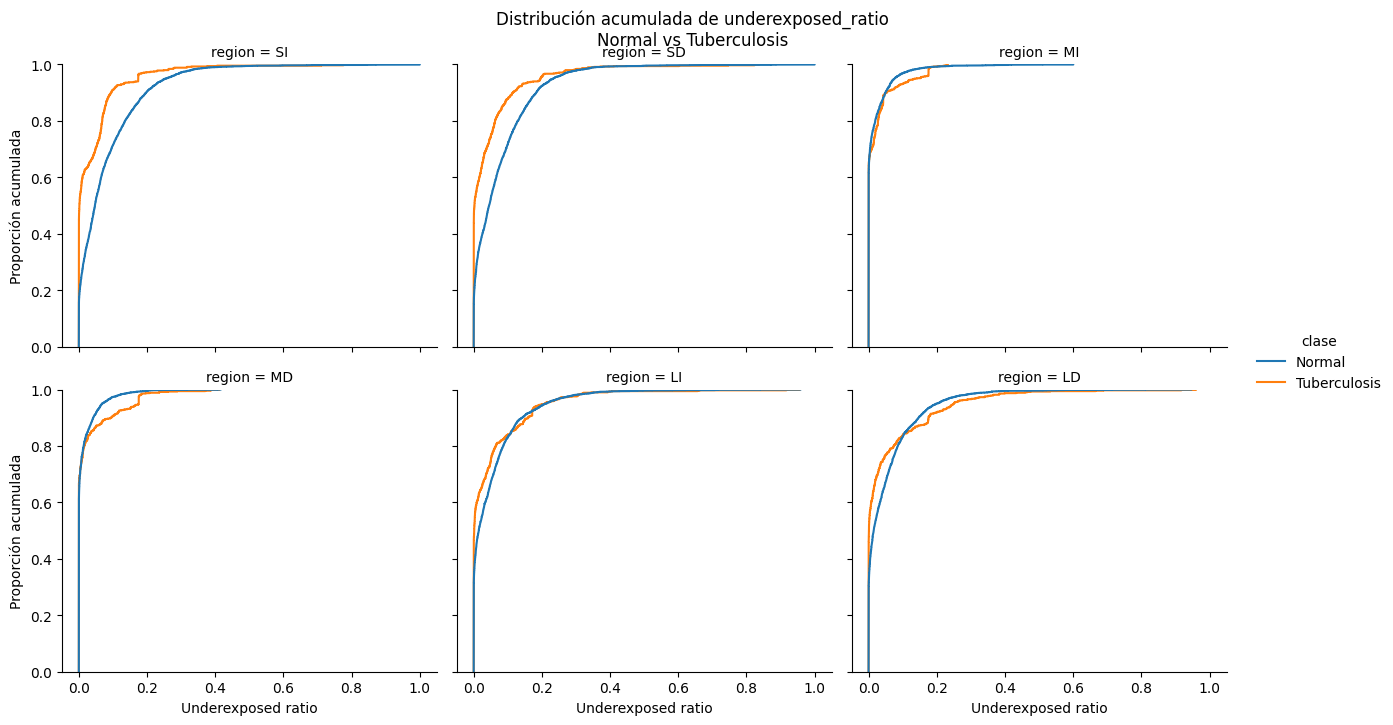

In [ ]:
g = sns.displot(
    data=regional_quality_long_df,
    x="underexposed_ratio",
    hue="clase",
    col="region",
    col_wrap=3,
    kind="ecdf",
    height=3.5,
    aspect=1.2
)
g.set_axis_labels("Underexposed ratio","Proporción acumulada")
g.fig.suptitle("Distribución acumulada de underexposed_ratio\n""Normal vs Tuberculosis",y=1.03)
plt.show()

El underexposed_ratio, proporción de píxeles casi negros, muestra diferencias entre clases que dependen de la región. En las zonas superiores (SI y SD), las imágenes con tuberculosis presentan en general menores proporciones de píxeles casi negros y además una mayor fracción de casos con underexposed_ratio = 0. En las regiones medias (MI y MD) ambas clases concentran muchos valores en cero, aunque las colas superiores difieren, mientras que en las regiones inferiores (LI y LD) las diferencias son más moderadas.

### Overexposed_ratio

Metrica complementaria de underexposed_ratio

In [ ]:
over_resumen = (regional_quality_long_df.groupby(["region", "clase"],observed=True)["overexposed_ratio"].agg(
        count="count",
        median="median",
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        P95=lambda x: x.quantile(0.95),
        P99=lambda x: x.quantile(0.99),
        # % de regiones que NO tienen ningun píxel > 250
        pct_cero=lambda x: (x == 0).mean() * 100,
        # % de regiones donde si aparece al menos un píxel > 250
        pct_no_cero=lambda x: (x > 0).mean() * 100
    )
)

over_resumen.round(5)

count  median   Q1       Q3      P95      P99  pct_cero  \
region clase                                                                   
SI     Normal         3500     0.0  0.0  0.00000  0.00329  0.00763  75.74286   
       Tuberculosis    700     0.0  0.0  0.00000  0.05361  0.14049  85.42857   
SD     Normal         3500     0.0  0.0  0.00014  0.00251  0.00843  67.00000   
       Tuberculosis    700     0.0  0.0  0.00000  0.00636  0.77645  87.42857   
MI     Normal         3500     0.0  0.0  0.00000  0.00000  0.00288  95.25714   
       Tuberculosis    700     0.0  0.0  0.00000  0.00000  0.07649  95.28571   
MD     Normal         3500     0.0  0.0  0.00000  0.00000  0.00196  95.60000   
       Tuberculosis    700     0.0  0.0  0.00000  0.00295  0.77395  92.71429   
LI     Normal         3500     0.0  0.0  0.00017  0.00338  0.01295  62.85714   
       Tuberculosis    700     0.0  0.0  0.05374  0.24089  1.00000  65.14286   
LD     Normal         3500     0.0  0.0  0.00007  0.00267  0.01211  68.37143   
       Tuberculosis    700     0.0  0.0  0.08321  0.30234  1.00000  63.14286   

                     pct_no_cero  
region clase                      
SI     Normal           24.25714  
       Tuberculosis     14.57143  
SD     Normal           33.00000  
       Tuberculosis     12.57143  
MI     Normal            4.74286  
       Tuberculosis      4.71429  
MD     Normal            4.40000  
       Tuberculosis      7.28571  
LI     Normal           37.14286  
       Tuberculosis     34.85714  
LD     Normal           31.62857  
       Tuberculosis     36.85714

In [ ]:
over_positivos = regional_quality_long_df[regional_quality_long_df["overexposed_ratio"] > 0].copy()

print("Regiones totales:",len(regional_quality_long_df))

print("Regiones con overexposed_ratio > 0:",len(over_positivos))

print("Porcentaje:", round(len(over_positivos)/len(regional_quality_long_df)*100, 2), "%")

Regiones totales: 25200
Regiones con overexposed_ratio > 0: 5507
Porcentaje: 21.85 %


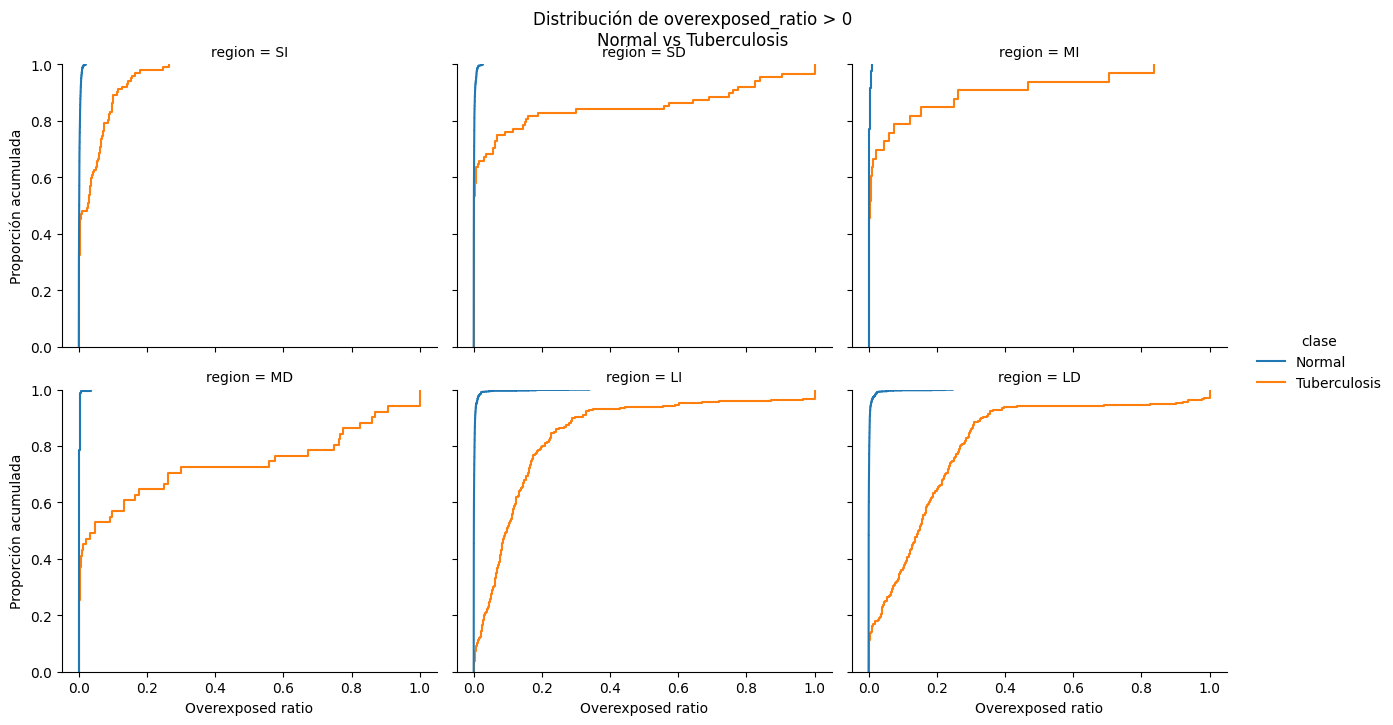

In [ ]:
g = sns.displot(
    data=over_positivos,
    x="overexposed_ratio",
    hue="clase",
    col="region",
    col_wrap=3,
    kind="ecdf",
    height=3.5,
    aspect=1.2
)

g.set_axis_labels("Overexposed ratio","Proporción acumulada")
g.fig.suptitle("Distribución de overexposed_ratio > 0\n""Normal vs Tuberculosis",y=1.03)
plt.show()

## Significancia y magnitud de las diferencias por región y clase

No usamos t-student para medir si existen diferencias estadísticas significativas en las métricas de cada región entre los pacientes con TB y los pacientes sanos, porque esta asume que hay normalidad de ambas poblaciones y homogeneidad de varianzas y esto no lo cumplen nuestros datos, pues en `blur_score` $P_{50}=66$ pero $P_{95} = 529$. `underexposed_ratio` tiene demasiadas muestras en 0 y en `noise_estimate` en TB muestra valores repeditos.

En ese caso, usaremos **Mann-Whitney U** que no asume ninguna distribución y $H_0: P(X>Y) = P (Y>X)$, es decir, las observaciones de un grupo no tiende a tener valores mayores que el otro.

In [ ]:
from scipy.stats import mannwhitneyu
# preparamos el dataframe para el test
metricas = ["brightness","contrast","entropy","blur_score","underexposed_ratio","overexposed_ratio","noise_estimate"]
regiones = ["SI", "SD", "MI", "MD", "LI", "LD"]
resultados = []

for region in regiones:
    subset = regional_quality_long_df[regional_quality_long_df["region"] == region]

    grupo_normal = subset.loc[subset["clase"] == "Normal"]
    grupo_tb = subset.loc[subset["clase"] == "Tuberculosis"]

    for metrica in metricas:
        x = grupo_normal[metrica].to_numpy(dtype=float)
        y = grupo_tb[metrica].to_numpy(dtype=float)

        result = mannwhitneyu(x, y, alternative="two-sided")

        resultados.append({
            "region": region,
            "metrica": metrica,
            "U_stat": result.statistic,
            "p_value": result.pvalue,
            "n_normal": len(x),
            "n_tb": len(y)
        })
df_mannwhitney = pd.DataFrame(resultados)
df_mannwhitney

,region,metrica,U_stat,p_value,n_normal,n_tb
0,SI,brightness,764523.0,1.050231e-55,3500,700
1,SI,contrast,1751585.0,2.774912e-72,3500,700
2,SI,entropy,1661348.0,3.334153e-50,3500,700
3,SI,blur_score,2248681.0,1.129676e-267,3500,700
4,SI,underexposed_ratio,1690676.0,3.032065e-57,3500,700
5,SI,overexposed_ratio,1317529.0,1.624362e-05,3500,700
6,SI,noise_estimate,2409988.0,0.000000e+00,3500,700
7,SD,brightness,881656.0,9.651132e-32,3500,700
8,SD,contrast,1722098.0,1.288872e-64,3500,700
9,SD,entropy,1723197.0,6.797194e-65,3500,700


$p$ solo nos dice, si realmente no existiera una diferencia sistemática entre los grupos Normal y TB, ¿qué tan compatible sería obtener una estadística $U$ tan extrema como la observada?, es decir, **p-valor** responde a si hay o no diferencia.

En este caso vemos que practicamente todas las metricas en todas las regiones -- a excpeción de `underexposed_ratio`$\approx 0.6395$ en MI y `overexposed_ratio`$\approx 0.9293$ en MI -- difieren entre TB y sanos, siendo posibles candidatas para ser usadas para detección

Sin embargo, un p-valor pequeño no indica que la diferencia sea grande ni que la métrica tenga una elevada capacidad discriminativa. Para cuantificar la magnitud y dirección de la diferencia utilizamos **rank_biserial correlation**

$r_{rb} = +1$: todas las observaciones del grupo 1 superan a todas las del grupo 2

$r_{rb} = -1$: Todas las muestras del grupo 2 superan a todas la del 1

$r_{rb} = 0$: No hay tendencia de un grupo sober otro

Aplicamos formula: $r_{rb}=\frac{2U}{n_1n_2}-1$

In [ ]:
df_mannwhitney["rank_biserial"] = (2 * df_mannwhitney["U_stat"]/(df_mannwhitney["n_normal"]*df_mannwhitney["n_tb"])- 1)

In [ ]:
#df_mannwhitney["abs_rank_biserial"] = df_mannwhitney["rank_biserial"].abs()

In [ ]:
df_mannwhitney.sort_values("rank_biserial", ascending=False, inplace=True)

In [ ]:
df_mannwhitney.reset_index(drop=True, inplace=True)

In [ ]:
df_mannwhitney

,region,metrica,U_stat,p_value,n_normal,n_tb,rank_biserial
0,MD,noise_estimate,2420690.0,0.000000e+00,3500,700,0.976073
1,MI,noise_estimate,2418046.0,0.000000e+00,3500,700,0.973915
2,LD,noise_estimate,2414540.5,0.000000e+00,3500,700,0.971053
3,SD,noise_estimate,2413860.5,0.000000e+00,3500,700,0.970498
4,LI,noise_estimate,2412596.5,0.000000e+00,3500,700,0.969467
5,SI,noise_estimate,2409988.0,0.000000e+00,3500,700,0.967337
6,SD,blur_score,2363186.0,0.000000e+00,3500,700,0.929131
7,MI,blur_score,2336977.0,0.000000e+00,3500,700,0.907736
8,MD,blur_score,2311146.0,4.587482e-301,3500,700,0.886650
9,SI,blur_score,2248681.0,1.129676e-267,3500,700,0.835658


Tomando unicamente donde $\lvert r_{rb} \rvert>0.50$, vemos que metricas en que regiones tiene una diferencia más fuerte, vemos que es `noise_estimate` Y `blur_score` en todas las regiones y `entropy` en MI y MD

Como se están realizando múltiples pruebas estadísticas (una prueba para cada combinación de métrica y región), aumenta el riesgo de obtener falsos positivos (que NO haya diferencia en la realidad, pero detecte que SÍ la hay) simplemente por realizar muchas pruebas.

Por ello aplicamos la corrección de **Benjamini-Hochberg** que nos dá los **q-values** que permiten evaluar la significancia estadística teniendo en cuenta el conjunto de pruebas realizadas

In [ ]:
from statsmodels.stats.multitest import multipletests
# Benjamini-Hochberg FDR
reject, pvals_corrected, _, _ = multipletests(df_mannwhitney["p_value"],alpha=0.05,method="fdr_bh")
df_mannwhitney["reject_H0"] = reject
df_mannwhitney["q_value"] = pvals_corrected
df_mannwhitney["abs_rank_biserial"] = df_mannwhitney["rank_biserial"].abs()

df_mannwhitney = (df_mannwhitney.sort_values("abs_rank_biserial", ascending=False).reset_index(drop=True))

df_mannwhitney.round(4)

,region,metrica,U_stat,p_value,n_normal,n_tb,rank_biserial,reject_H0,q_value,abs_rank_biserial
0,MD,noise_estimate,2420690.0,0.0000,3500,700,0.9761,True,0.0000,0.9761
1,MI,noise_estimate,2418046.0,0.0000,3500,700,0.9739,True,0.0000,0.9739
2,LD,noise_estimate,2414540.5,0.0000,3500,700,0.9711,True,0.0000,0.9711
3,SD,noise_estimate,2413860.5,0.0000,3500,700,0.9705,True,0.0000,0.9705
4,LI,noise_estimate,2412596.5,0.0000,3500,700,0.9695,True,0.0000,0.9695
5,SI,noise_estimate,2409988.0,0.0000,3500,700,0.9673,True,0.0000,0.9673
6,SD,blur_score,2363186.0,0.0000,3500,700,0.9291,True,0.0000,0.9291
7,MI,blur_score,2336977.0,0.0000,3500,700,0.9077,True,0.0000,0.9077
8,MD,blur_score,2311146.0,0.0000,3500,700,0.8866,True,0.0000,0.8866
9,SI,blur_score,2248681.0,0.0000,3500,700,0.8357,True,0.0000,0.8357


Cuanto menor sea el **q-value**, mayor es la evidencia estadística contra $H_0$.

Después de aplicar Benjamini-Hochberg, la gran mayoría de las diferencias continúa siendo estadísticamente significativa $q<0.05$. Las excepciones son underexposed_ratio en MD y MI y overexposed_ratio en MI, para las cuales no existe evidencia estadística suficiente para rechazar $H_0$

In [ ]:
hallazgos_fuertes = df_mannwhitney[(df_mannwhitney["reject_H0"] == True) &(df_mannwhitney["abs_rank_biserial"] >= 0.5)]
hallazgos_fuertes

,region,metrica,U_stat,p_value,n_normal,n_tb,rank_biserial,reject_H0,q_value,abs_rank_biserial
0,MD,noise_estimate,2420690.0,0.000000e+00,3500,700,0.976073,True,0.000000e+00,0.976073
1,MI,noise_estimate,2418046.0,0.000000e+00,3500,700,0.973915,True,0.000000e+00,0.973915
2,LD,noise_estimate,2414540.5,0.000000e+00,3500,700,0.971053,True,0.000000e+00,0.971053
3,SD,noise_estimate,2413860.5,0.000000e+00,3500,700,0.970498,True,0.000000e+00,0.970498
4,LI,noise_estimate,2412596.5,0.000000e+00,3500,700,0.969467,True,0.000000e+00,0.969467
5,SI,noise_estimate,2409988.0,0.000000e+00,3500,700,0.967337,True,0.000000e+00,0.967337
6,SD,blur_score,2363186.0,0.000000e+00,3500,700,0.929131,True,0.000000e+00,0.929131
7,MI,blur_score,2336977.0,0.000000e+00,3500,700,0.907736,True,0.000000e+00,0.907736
8,MD,blur_score,2311146.0,4.587482e-301,3500,700,0.886650,True,2.140825e-300,0.886650
9,SI,blur_score,2248681.0,1.129676e-267,3500,700,0.835658,True,4.744638e-267,0.835658


Despues de usar Benjamini–Hochberg, notamos que noise_estimate, blur_score y en las regiones MI y MD, entropy, presentan diferencias estadísticamente significativas y de gran magnitud entre las clases Normal y Tuberculosis. Por tanto, son las principales candidatas univariadas a aportar capacidad discriminativa entre ambas clases dentro de este dataset.

- **`noise_estimate`**: Normal tiende a presentar mayor `noise_estimate` que TB
- **`blur_score`**: Normal tiende a presentar mayor `blur_score` que TB, en todas las regiones, pero especialmente fuerte en las zonas superiores y medias.
- **`entropy`**: Aunque tambien tiene a que Normal presenta mayor `entropy` que TB, la diferencia es fuerte en las zonas medias.

## Correlacion entre metricas

**En todo el dataset y considerando todas las regiones juntas, ¿qué métricas tienden a variar conjuntamente?**

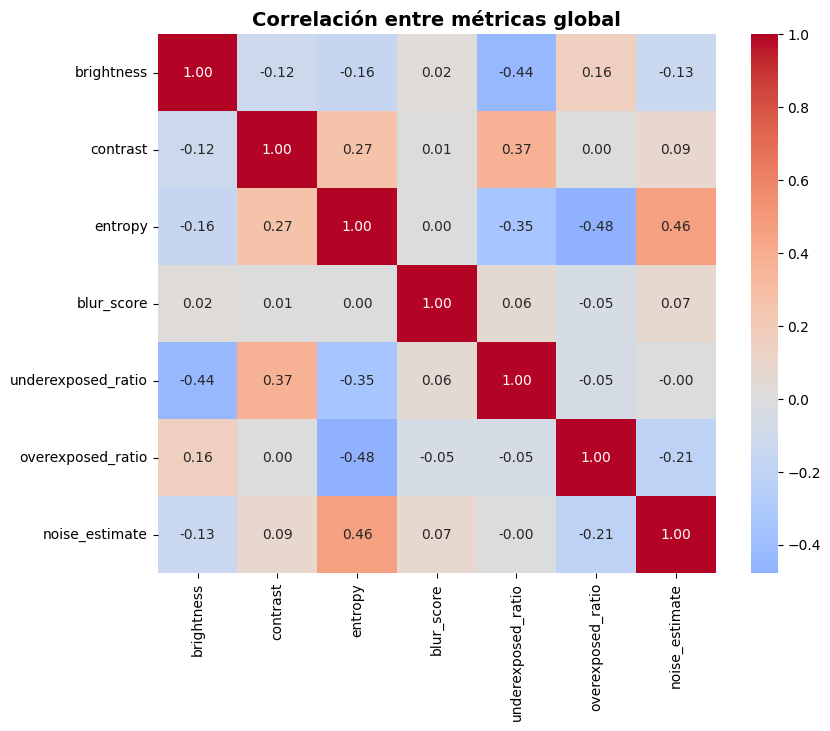

In [ ]:
metricas_calidad = ["brightness","contrast","entropy","blur_score","underexposed_ratio","overexposed_ratio","noise_estimate"]

corr_metricas = regional_quality_long_df[metricas_calidad].corr()

plt.figure(figsize=(9,7))

sns.heatmap(corr_metricas,annot=True,fmt=".2f",cmap="coolwarm",center=0)

plt.title("Correlación entre métricas global",fontsize=14,fontweight="bold")

plt.show()

La mayoría de las métricas no presenta correlaciones lineales extremadamente altas, por lo que no se observa una redundancia general evidente entre ellas. Las relaciones de mayor magnitud son `entropy` y `overexposed_ratio` (negativa), `entropy` y `noise_estimate` (positiva), y `brightness` y `underexposed_ratio` (negativa).

Precisamente `noise_estimate` y `blur_score`, las métricas con mayores tamaños de efecto para diferenciar las clases, presentan una correlación global baja, esto debe estudiarse

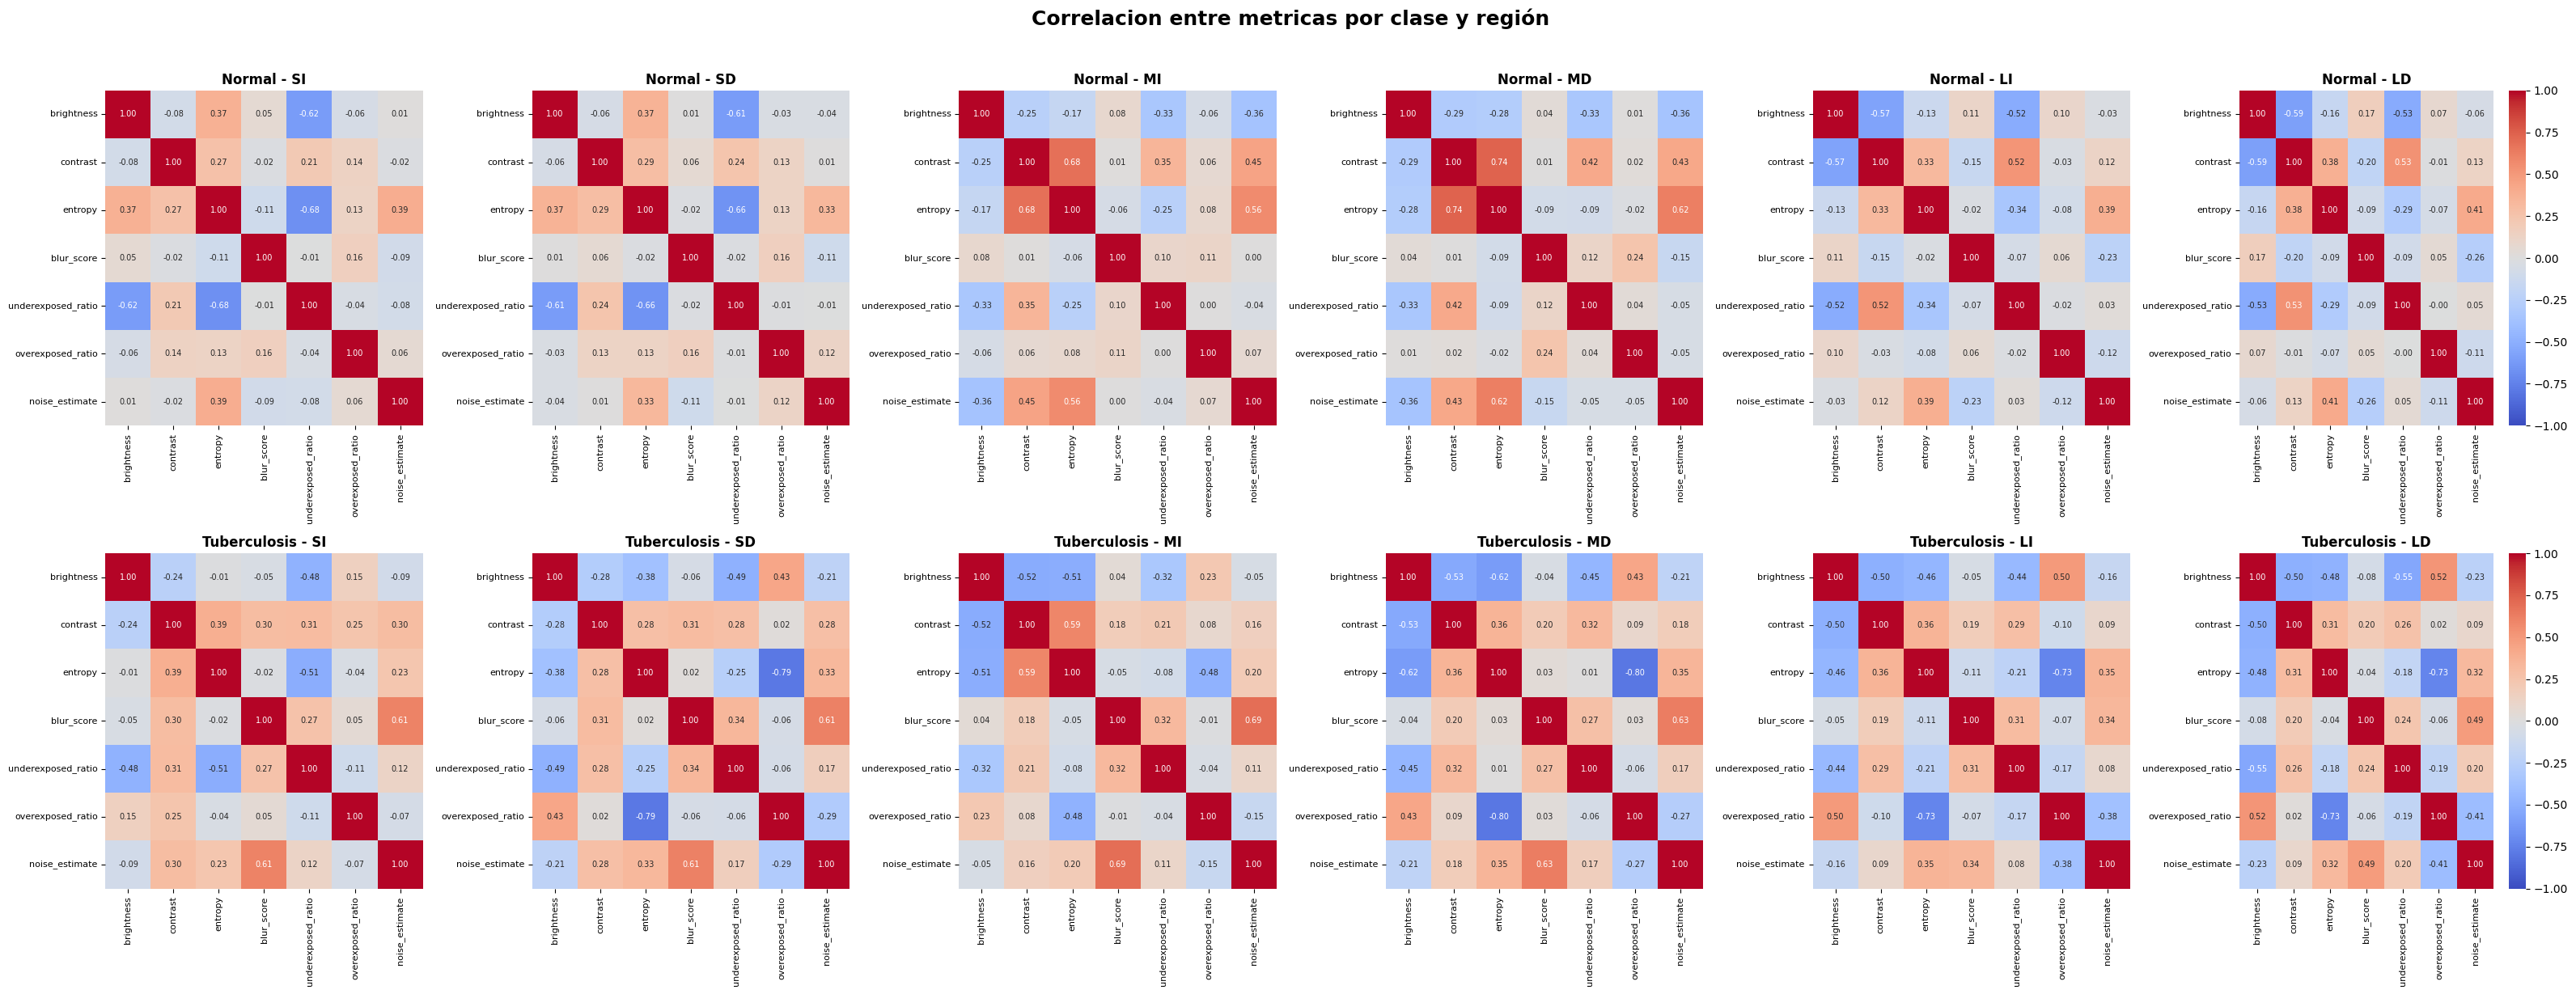

In [ ]:
clases = ["Normal", "Tuberculosis"]
regiones = ["SI", "SD", "MI", "MD", "LI", "LD"]

fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(32, 12))

for i, clase in enumerate(clases):
    for j, region in enumerate(regiones):
        subset = regional_quality_long_df[(regional_quality_long_df["clase"] == clase) & (regional_quality_long_df["region"] == region)]
        corr = subset[metricas_calidad].corr()
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[i, j], cbar=(j == len(regiones) - 1), annot_kws={"size": 7})

        axes[i, j].set_title(f"{clase} - {region}", fontsize=12, fontweight="bold")

        axes[i, j].tick_params(axis="x", labelrotation=90, labelsize=8)

        axes[i, j].tick_params(axis="y", labelrotation=0, labelsize=8)

fig.suptitle("Correlacion entre metricas por clase y región", fontsize=18, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

### Análisis de correlaciones entre las métricas candidatas

Los heatmaps anteriores muestran que la estructura de correlación no es idéntica entre clases ni entre regiones. Algunas asociaciones cambian al pasar de `Normal` a `Tuberculosis`, lo que indica que una única matriz de correlación global puede ocultar relaciones específicas de cada grupo

Esto es especialmente relevante porque, en el análisis anterior basado en Mann–Whitney, corrección de Benjamini–Hochberg y tamaño del efecto mediante rank-biserial, las métricas que mostraron mayor capacidad de separación entre las clases fueron principalmente:

- `noise_estimate`
- `blur_score`
- `entropy` en algunas regiones

Aunnque algunas métricas presenten diferencias fuertes entre Normal y TB no significa que todas aporten información diferente, pueden tener correlacion elevada

Se construye una tabla de relaciones entre las principales métricas candidatas, analizando:

- `noise_estimate <-> blur_score`
- `noise_estimate <-> entropy`
- `blur_score <-> entropy`

Estas relaciones permiten evaluar si las métricas candidatas parecen ser redundantes o capturan propiedades distintas.

También se incluyen algunas relaciones diagnósticas con métricas básicas de la imagen, como:

- `noise_estimate <-> contrast`
- `blur_score <-> contrast`
- `entropy <-> overexposed_ratio`

El objetivo de estas relaciones adicionales es comprobar si las métricas candidatas están fuertemente condicionadas por propiedades más simples.

In [ ]:
pares_interes = [("noise_estimate", "blur_score"), ("noise_estimate", "entropy"), ("blur_score", "entropy")]
resumen_correlaciones = []

for clase in clases:
    for region in regiones:
        subset = regional_quality_long_df[(regional_quality_long_df["clase"] == clase) & (regional_quality_long_df["region"] == region)]
        corr = subset[metricas_calidad].corr(method="spearman")
        resumen_correlaciones.append({
            "clase": clase,
            "region": region,
            "noise_estimate <-> blur_score": corr.loc["noise_estimate", "blur_score"],
            "noise_estimate <-> entropy": corr.loc["noise_estimate", "entropy"],
            "blur_score <-> entropy": corr.loc["blur_score", "entropy"],
            "noise_estimate <-> contrast": corr.loc["noise_estimate", "contrast"],
            "blur_score <-> contrast": corr.loc["blur_score", "contrast"],
            "entropy <-> overexposed_ratio": corr.loc["entropy", "overexposed_ratio"]
        })

df_corr_resumen = pd.DataFrame(resumen_correlaciones)
df_corr_resumen

,clase,region,noise_estimate <-> blur_score,noise_estimate <-> entropy,blur_score <-> entropy,noise_estimate <-> contrast,blur_score <-> contrast,entropy <-> overexposed_ratio
0,Normal,SI,-0.014730,0.372820,0.123514,-0.022668,0.123273,0.187939
1,Normal,SD,0.023585,0.400316,0.104056,0.046957,0.165478,0.153298
2,Normal,MI,0.190897,0.613810,0.051344,0.483053,0.179134,0.150468
3,Normal,MD,0.270558,0.628858,0.198197,0.435865,0.302692,0.016443
4,Normal,LI,-0.248106,0.398963,0.165669,0.107255,-0.141158,0.023230
5,Normal,LD,-0.246871,0.426443,0.050345,0.107201,-0.214907,-0.023706
6,Tuberculosis,SI,0.260266,0.452015,-0.008405,0.316863,0.464209,0.078889
7,Tuberculosis,SD,0.274118,0.499166,-0.042859,0.338783,0.324616,-0.039346
8,Tuberculosis,MI,0.365528,0.423798,0.052053,0.327857,0.224510,0.114647
9,Tuberculosis,MD,0.302144,0.561750,0.097599,0.340901,0.212667,-0.000085


Las métricas candidatas no presentan correlaciones lineales suficientemente altas como para considerarlas redundantes.

**`noise_estimate` y `blur_score`**  
Su relación es débil y varía según clase y región. En imágenes normales las correlaciones están aproximadamente entre -0.25 y 0.27, mientras que en tuberculosis son positivas y algo mayores. Aunque ambas métricas separan bien las clases, no parecen medir exactamente la misma propiedad.

**`noise_estimate` y `entropy`**  
Es la relación más consistente. Presentan correlaciones positivas moderadas en ambas clases, especialmente en las regiones medias de las imágenes normales. Esto sugiere que comparten parte de la información, pero no son equivalentes ni claramente redundantes.

**`blur_score` y `entropy`**  
Las correlaciones son cercanas a cero en casi todas las combinaciones clase-región, por lo que parecen describir propiedades diferentes.

**Relaciones con otras métricas**  
`noise_estimate` y `blur_score` muestran asociaciones moderadas con `contrast` solo en algunas regiones, sin un patrón fuerte y constante. Por otro lado, `entropy` y `overexposed_ratio` presentan correlaciones cercanas a cero al analizar clase y región por separado, lo que indica que su correlación global estaba probablemente influenciada por la mezcla de grupos.

En general, las métricas candidatas no parecen ser simples reflejos de propiedades básicas como contraste o sobreexposición, parecen contener información propia.

### Conclusión general

`noise_estimate`, `blur_score` y `entropy` parecen contener información parcialmente distinta. La relación más importante se da entre `noise_estimate` y `entropy`, pero sigue siendo moderada. No se observa una redundancia lineal fuerte entre las métricas candidatas, por lo que tiene sentido evaluar posteriormente su contribución conjunta en el modelado predictivo.

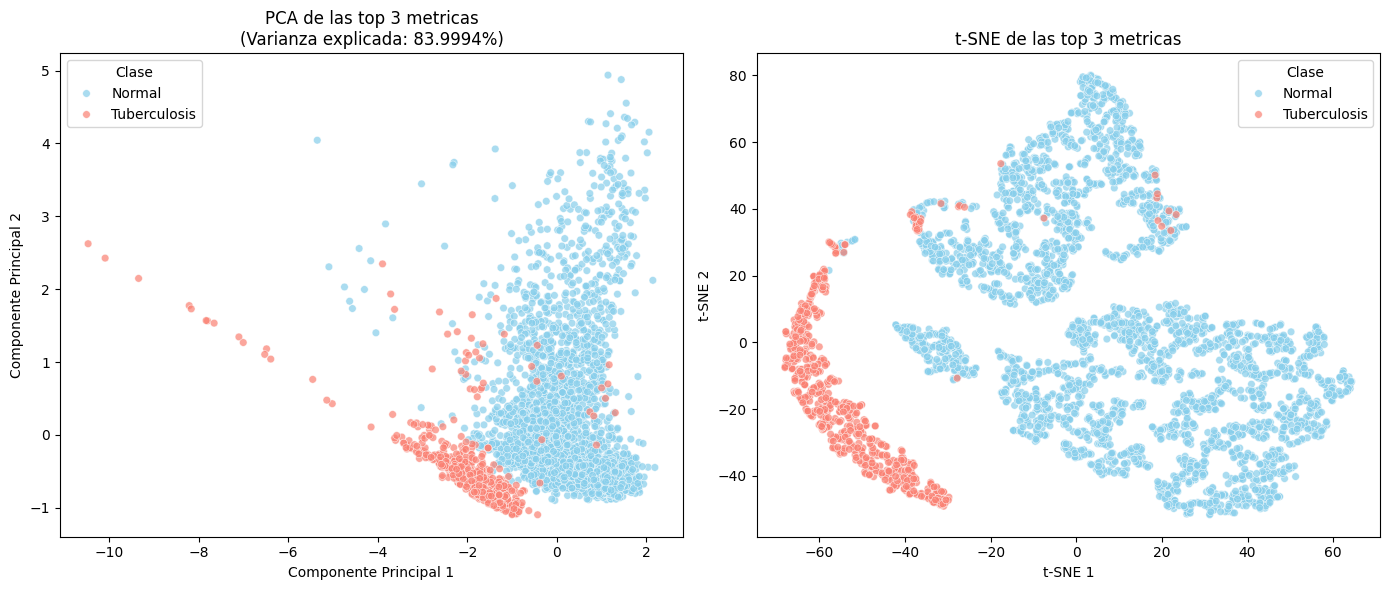

In [ ]:
#Identificar las metricas top y crear promedio por imagen
metricas_top = ["noise_estimate", "blur_score", "entropy"]

for metrica in metricas_top:
    # Seleccionamos todas las columnas que terminan con el nombre de la metrica (SI_brightness, SI_contras, SI_entropy, SI_blur_score,...)
    cols = [col for col in regional_quality_df.columns if col.endswith(metrica)]
    # Creamos una nueva columna con el promedio de esa meétrica en todas las regiones
    regional_quality_df[f"mean_{metrica}"] = regional_quality_df[cols].mean(axis=1)

# preparar los datos X y las etiquetas y
features = [f"mean_{i}" for i in metricas_top]
X = regional_quality_df[features].values
y = regional_quality_df["clase"].values

# Escalar los datos (
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# aplicar PCA (2 componentes)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Aplicar t-SNE (2 componentes)
# t-SNE para visualizar agrupamientos no lineales
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Grafico PCA
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y,  palette={"Normal": "skyblue", "Tuberculosis": "salmon"},  alpha=0.7, ax=axes[0], s=30)
varianza_explicada = pca.explained_variance_ratio_.sum()
axes[0].set_title(f"PCA de las top 3 metricas\n(Varianza explicada: {varianza_explicada:.4%})")
axes[0].set_xlabel("Componente Principal 1")
axes[0].set_ylabel("Componente Principal 2")
axes[0].legend(title='Clase')

# Grafico t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y,  palette={"Normal": "skyblue", "Tuberculosis": "salmon"},  alpha=0.7, ax=axes[1], s=30)
axes[1].set_title("t-SNE de las top 3 metricas")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
axes[1].legend(title='Clase')

plt.tight_layout()
plt.show()

### PCA
- La clase Tuberculosis forma un cluster en la zona inferior izquierda, mientras que el cluster de Normal ocupa un espacio mucho más amplio y disperso.
- Con solo 2 componentes principales se captura el 84% de la variabilidad, esto nos dice que las 3 métricas seleccionadas contienen información util

### t-SNE
-  Revela que las clases son casi linealmente separables en el espacio de las 3 métricas, hay poca interesección
- La clase Normal forma varios subgrupos, lo que sugiere que hay heterogeneidad dentro de las imágenes normales.
- El cluster de Tuberculosis tiene una forma curva


### NOTA
Los outliers de TB merecen investigación para determinar si son casos reales con patología muy identificable o imágenes con artefactos, deberian visualizarse

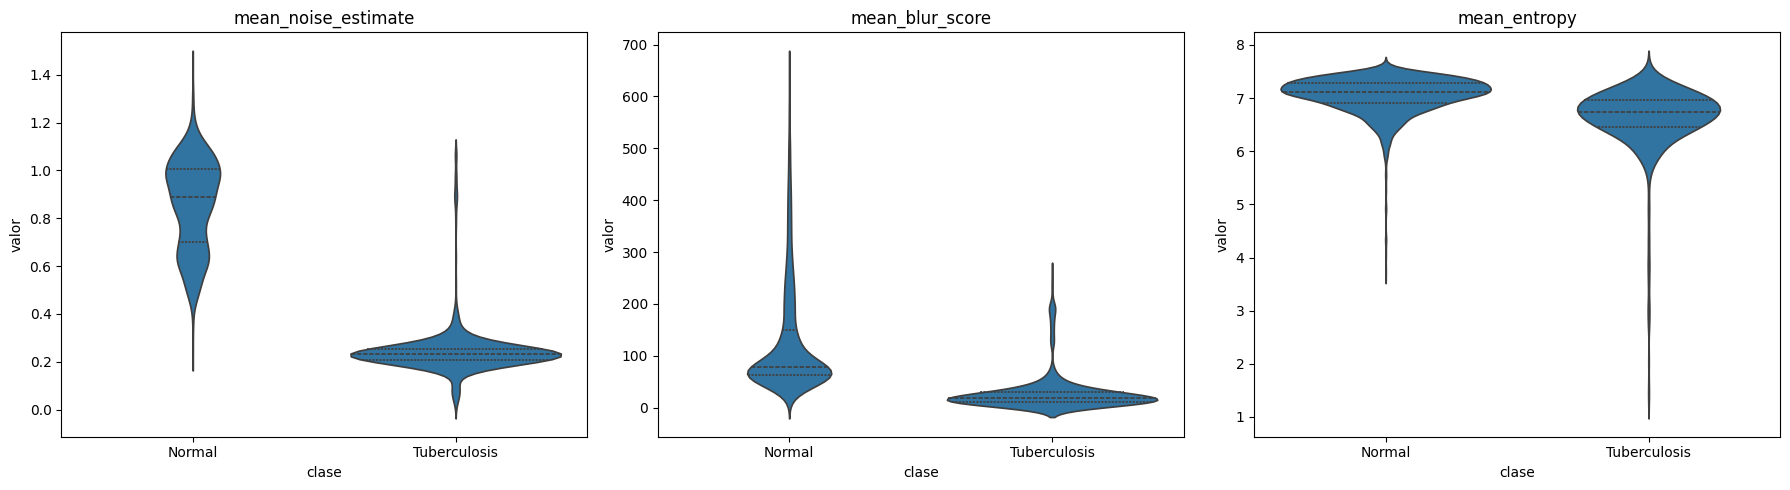

In [ ]:
metricas_mean = ["mean_noise_estimate", "mean_blur_score", "mean_entropy"]

df_violin = regional_quality_df[["clase"] + metricas_mean].melt(id_vars="clase", value_vars=metricas_mean, var_name="metrica", value_name="valor")

fig, axes = plt.subplots(1,3, figsize=(18,5))
for ax, metrica in zip(axes, metricas_mean):
    sns.violinplot(data=df_violin[df_violin["metrica"] == metrica], x="clase", y="valor", ax=ax, inner="quartile")
    ax.set_title(metrica)

plt.tight_layout()
plt.show()

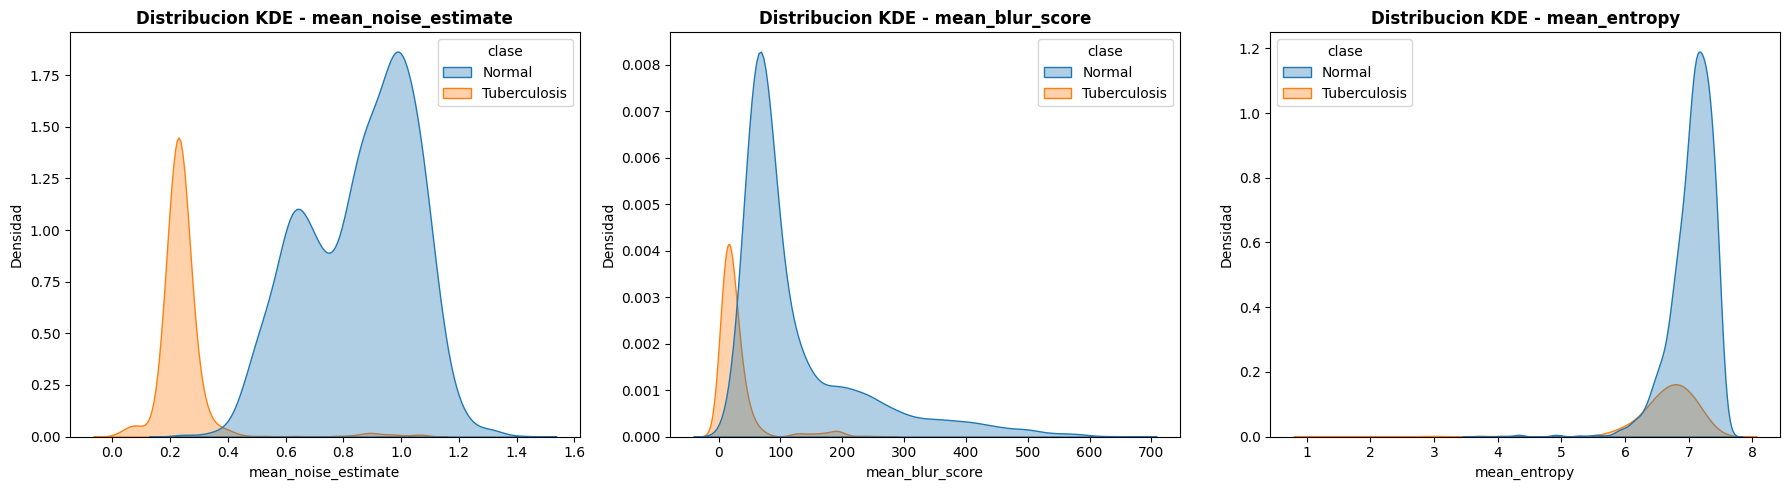

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, metrica in zip(axes, metricas_top):
    sns.kdeplot(data=regional_quality_df, x=metrica, hue="clase", fill=True, alpha=0.35, ax=ax)
    ax.set_title(f"Distribucion KDE - {metrica}", fontweight="bold")
    ax.set_xlabel(metrica)
    ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

- `mean_noise_estimate`: **Tuberculosis:** Distribución unimodal, muy estrecha y concentrada alrededor de 0.25. **Normal:** Distribución bimodal, mucho más dispersa. Esta es la métrica con mayor capacidad discriminativa
- `mean_blur_score`: **Tuberculosis:** Pico agudo cerca de 20 - 30, distribución muy concentrada. **Normal:** Pico principal alrededor de 60 - 80, con cola derecha muy larga que se extiende hasta 700, hay poco solapamiento.
- `mean_entropy`: **Tuberculosis:** Distribución estrecha, pico alrededor de 6.8 **Normal:** Distribución más ancha, pico alrededor de 7.2, hay un solapamiento considerable.

In [ ]:
tabla_distribucion = regional_quality_df[metricas_top].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T
tabla_distribucion

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
mean_noise_estimate,4200.0,0.755334,0.290023,0.023720,0.180078,0.215104,0.591628,0.834627,0.985887,1.107839,1.189552,1.426440
mean_blur_score,4200.0,109.902813,103.356337,2.254113,5.169387,12.885766,52.642299,72.367765,128.302590,348.523360,492.732631,647.103480
mean_entropy,4200.0,6.980746,0.450877,1.328812,5.615457,6.301148,6.810181,7.068286,7.258615,7.448489,7.523867,7.633581


In [ ]:
tabla_clases = (regional_quality_df.groupby("clase")[metricas_top].agg(["mean", "median", "std", "min", "max" ]))
tabla_clases

mean_noise_estimate                                         \
                            mean    median       std       min      max   
clase                                                                     
Normal                  0.857316  0.889992  0.189831  0.237933  1.42644   
Tuberculosis            0.245427  0.230548  0.111548  0.023720  1.06957   

             mean_blur_score                                                \
                        mean     median         std        min         max   
clase                                                                        
Normal            126.110294  79.324153  104.712951  20.533398  647.103480   
Tuberculosis       28.865411  18.224639   37.324317   2.254113  259.470072   

             mean_entropy                                          
                     mean    median       std       min       max  
clase                                                              
Normal           7.052383  7.115971  0.355865  3.657383  7.633581  
Tuberculosis     6.622558  6.730839  0.658101  1.328812  7.536260

In [ ]:
regional_quality_df.to_csv("regional_quality_df.csv", index=False)